<a href="https://colab.research.google.com/github/isaacadebayo/Predictive-Analytics-Public-Datasets/blob/main/Apple_Stock_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
stocks = pd.read_csv('/content/drive/MyDrive/aapl_stock_prices.csv')
stocks.head()

,Date,Open,High,Low,Close,Volume
0,1980-12-12,0.098297,0.098725,0.098297,0.098297,469033600
1,1980-12-15,0.093597,0.093597,0.093169,0.093169,175884800
2,1980-12-16,0.086758,0.086758,0.086331,0.086331,105728000
3,1980-12-17,0.088468,0.088895,0.088468,0.088468,86441600
4,1980-12-18,0.091032,0.091460,0.091032,0.091032,73449600


In [4]:
stocks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11407 entries, 0 to 11406
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    11407 non-null  object 
 1   Open    11407 non-null  float64
 2   High    11407 non-null  float64
 3   Low     11407 non-null  float64
 4   Close   11407 non-null  float64
 5   Volume  11407 non-null  int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 534.8+ KB


<Axes: xlabel='Date'>

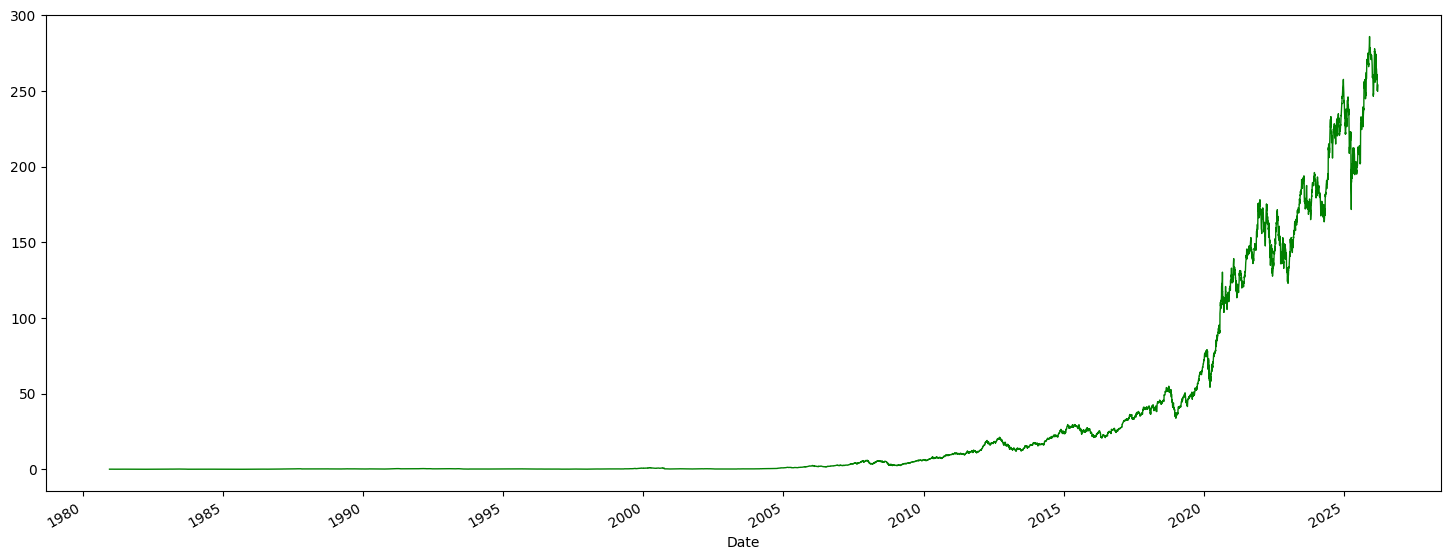

In [5]:
if 'Date' in stocks.columns:
    stocks['Date'] = pd.to_datetime(stocks['Date'])
    stocks = stocks.set_index('Date')
stocks.Close.plot(figsize=(18,7), linewidth=1, c='g')

,count,mean,std,min,25%,50%,75%,max
Open,11407.0,0.101247,0.208832,0.0,0.000730,0.001587,0.076311,1.0
High,11407.0,0.101485,0.209296,0.0,0.000747,0.001608,0.076484,1.0
Low,11407.0,0.101240,0.208877,0.0,0.000720,0.001572,0.076457,1.0
Close,11407.0,0.101326,0.209009,0.0,0.000733,0.001592,0.076348,1.0
Volume,11407.0,0.041573,0.044884,0.0,0.014212,0.026584,0.052385,1.0


,Open,High,Low,Close,Volume
Open,1.000000,0.999937,0.999940,0.999873,-0.287284
High,0.999937,1.000000,0.999918,0.999943,-0.287010
Low,0.999940,0.999918,1.000000,0.999942,-0.287684
Close,0.999873,0.999943,0.999942,1.000000,-0.287359
Volume,-0.287284,-0.287010,-0.287684,-0.287359,1.000000


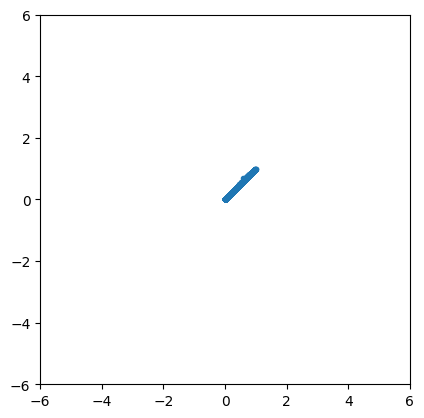

In [6]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X = scaler.fit_transform(stocks)

df_X_data = pd.DataFrame(X, columns=stocks.columns)
display(df_X_data.describe().T)
display(df_X_data.corr())

plt.plot( X[:,0], X[:,1], '.' )
plt.xlim(-6,6)
plt.ylim(-6,6)
plt.gca().set_aspect('equal')

In [7]:
# Create lagged sequences
window_size = 10

#perm = np.arange(window_size)
perm = np.random.permutation(np.arange(window_size))

X, y = [], []
dates = []
for i in range(len(stocks) - window_size):
    X.append(stocks.iloc[i:i+window_size].values)
    # Predict only the 'close' price (index 1) for y
    y.append(stocks.iloc[i+window_size, 1])
    dates.append(stocks.index[i+window_size])

X = np.array(X)
y = np.array(y)
dates = np.array(dates)

print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (11397, 10, 5), y shape: (11397,)


In [8]:
# Simple index-based split
split_idx = int(len(X) * 0.9)
X_train, y_train, dates_train = X[:split_idx], y[:split_idx], dates[:split_idx]
X_test, y_test, dates_test = X[split_idx:], y[split_idx:], dates[split_idx:]

# Reshape X_train and X_test to be 2D for scikit-learn models
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

print(f"Train: X={X_train.shape}, y={y_train.shape}")
print(f"Test:  X={X_test.shape}, y={y_test.shape}")

Train: X=(10257, 50), y=(10257,)
Test:  X=(1140, 50), y=(1140,)


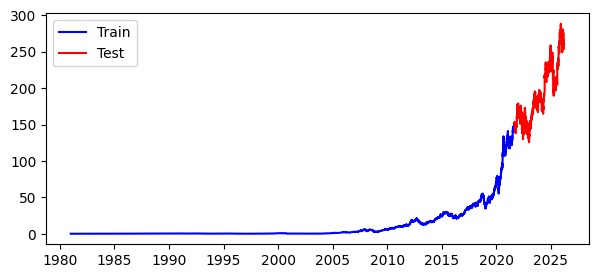

In [9]:
plt.figure(figsize=(7,3))
# y_train and y_test are now 1D arrays
plt.plot( dates_train, y_train, 'b', label='Train' );
plt.plot( dates_test, y_test, 'r', label='Test' );
plt.legend()

# Cross Validation

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

models = [
    LinearRegression(),
    KNeighborsRegressor(n_neighbors=4, weights='uniform'),
    RandomForestRegressor(n_estimators=10, max_depth=5),
    RandomForestRegressor(n_estimators=30, max_depth=10),
    GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=2),
    GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3),
    GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5),
]

In [11]:
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits=5, shuffle=True)

# Reshape X to be 2-dimensional for scikit-learn models
X_2d = X.reshape(X.shape[0], -1)

for m in models:
    print(m)

    cv_scores = -cross_val_score(m, X_2d, y, cv=kf, scoring='neg_mean_absolute_percentage_error')
    cv_scores = pd.DataFrame(cv_scores)
    display(cv_scores.describe().T)

    print()
# end

LinearRegression()


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.043947,0.009048,0.030268,0.040855,0.04579,0.048587,0.054236



KNeighborsRegressor(n_neighbors=4)


,count,mean,std,min,25%,50%,75%,max
0,5.0,107.299938,5.474719,99.21624,105.02014,108.660346,109.93493,113.668034



RandomForestRegressor(max_depth=5, n_estimators=10)


...

,count,mean,std,min,25%,50%,75%,max
0,5.0,0.165478,0.009817,0.155032,0.157495,0.164178,0.172481,0.178202



GradientBoostingRegressor()


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.097569,0.004521,0.090591,0.097208,0.097953,0.098969,0.103123



GradientBoostingRegressor(max_depth=5)


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.041145,0.001283,0.040144,0.040461,0.040535,0.041267,0.043318


# Grid SearchCV

In [12]:
from sklearn.model_selection import GridSearchCV

# Define models and their parameter grids
param_grids = {
    "KNeighborsRegressor": (
        KNeighborsRegressor(),
        {
            "n_neighbors": [1, 5, 10, 20, 50],
            "weights": ["uniform", "distance"]
        }
    ),

    "RandomForestRegressor": (
        RandomForestRegressor(),
        {
            "n_estimators": [10, 50, 100],
            "max_depth": [3, 5, 10],
            "min_samples_split": [2, 5, 10],
            'min_samples_leaf': [1, 2, 5, 10]
        }
    ),

    "GradientBoostingRegressor": (
        GradientBoostingRegressor(),
        {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.01, 0.1, 0.2],
            "max_depth": [2, 3, 5],
            'min_samples_leaf': [1, 2, 5, 10]
        }
    )
}

# Define cross-validation strategy
kf = KFold(n_splits=5, shuffle=True)

# Store results
results = []

# Perform GridSearchCV for each model
for name, (model, param_grid) in param_grids.items():
    print(f"Performing GridSearchCV for {name}...")

    grid_search = GridSearchCV(model, param_grid, cv=kf, scoring="neg_mean_absolute_percentage_error", n_jobs=-1)
    grid_search.fit(X_2d, y)

    best_params = grid_search.best_params_
    best_score = grid_search.best_score_

    results.append({"Model": name, "Best Score": best_score, "Best Params": best_params})
# end

results

Performing GridSearchCV for KNeighborsRegressor...
Performing GridSearchCV for RandomForestRegressor...
Performing GridSearchCV for GradientBoostingRegressor...


[{'Model': 'KNeighborsRegressor',
  'Best Score': np.float64(-105.78082889448424),
  'Best Params': {'n_neighbors': 1, 'weights': 'uniform'}},
 {'Model': 'RandomForestRegressor',
  'Best Score': np.float64(-0.017457633261259285),
  'Best Params': {'max_depth': 10,
   'min_samples_leaf': 1,
   'min_samples_split': 10,
   'n_estimators': 50}},
 {'Model': 'GradientBoostingRegressor',
  'Best Score': np.float64(-0.0411639261266382),
  'Best Params': {'learning_rate': 0.1,
   'max_depth': 5,
   'min_samples_leaf': 2,
   'n_estimators': 100}}]

# Feature Importance










In [15]:
# Fit a Random Forest model
rf = RandomForestRegressor(n_estimators=1000)
rf.fit(X_2d, y)

# Generate feature names for X_2d
original_features = stocks.columns.tolist()
feature_names_for_X_2d = []
for lag in range(window_size, 0, -1): # Lags from window_size down to 1
    for col in original_features:
        feature_names_for_X_2d.append(f'{col}_lag{lag}')

# Get feature importances
importances = pd.Series(rf.feature_importances_, index=feature_names_for_X_2d).sort_values(ascending=False)
importances = importances[:20]

# Get the names of the selected features
features_rf = importances.index.tolist()

# Create a DataFrame from X_2d with the correct column names for easier slicing
X_2d_df = pd.DataFrame(X_2d, columns=feature_names_for_X_2d)

# Select only the important features from X_2d_df
X_pars = X_2d_df[features_rf]

importances

,0
Close_lag1,0.537656
Low_lag1,0.211103
High_lag1,0.095955
Low_lag2,0.040476
Close_lag2,0.036984
Close_lag3,0.016790
Low_lag3,0.012310
Open_lag1,0.010812
High_lag2,0.009162
Open_lag2,0.009006


# KERAS

In [18]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 86.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 81.6 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay, PolynomialDecay
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def build_model( X_train, epochs, batch_size, decay_frac, initial_learning_rate, dropout_rate ):

    # Create model
    model = Sequential([
        Input(shape=X_train.shape[1]),
        Dense(20, activation='relu'),
        Dropout(dropout_rate),
        Dense(20, activation='relu'),
        Dropout(dropout_rate),
        Dense(20, activation='relu'),
        Dense(1, activation='relu'),
    ])

    # define training parameters
    decay_epochs    = int( epochs * decay_frac )
    n_train         = X_train.shape[0]
    steps_per_epoch = int( np.ceil( n_train / batch_size ) )
    decay_steps     = decay_epochs * steps_per_epoch

    lr_schedule_poly = PolynomialDecay(
        initial_learning_rate=initial_learning_rate,
        end_learning_rate=0.001,
        decay_steps=decay_steps,
        power=2.0
    )

    # Define the optimizer with a custom learning rate
    optimizer = Adam(
        learning_rate=lr_schedule_poly,
    )

    # Compile model
    model.compile(
        optimizer=optimizer,
        loss='mae'
    )

    return model
# end

In [21]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler # Import MinMaxScaler

# Re-defining build_model with the fix for the Input layer
from keras.models import Sequential
from keras.layers import *
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay, PolynomialDecay
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def build_model( X_train, epochs, batch_size, decay_frac, initial_learning_rate, dropout_rate ):

    # Create model
    model = Sequential([
        Input(shape=(X_train.shape[1], X_train.shape[2])), # Corrected: Input layer now expects 3D shape
        Flatten(), # Added: Flatten the input for Dense layers
        Dense(20, activation='relu'),
        Dropout(dropout_rate),
        Dense(20, activation='relu'),
        Dropout(dropout_rate),
        Dense(20, activation='relu'),
        Dense(1, activation='linear'), # Changed activation to 'linear' for regression
    ])

    # define training parameters
    decay_epochs    = int( epochs * decay_frac )
    n_train         = X_train.shape[0]
    steps_per_epoch = int( np.ceil( n_train / batch_size ) )
    decay_steps     = decay_epochs * steps_per_epoch

    lr_schedule_poly = PolynomialDecay(
        initial_learning_rate=initial_learning_rate,
        end_learning_rate=0.001,
        decay_steps=decay_steps,
        power=2.0
    )

    # Define the optimizer with a custom learning rate
    optimizer = Adam(
        learning_rate=lr_schedule_poly,
    )

    # Compile model
    model.compile(
        optimizer=optimizer,
        loss='mae'
    )

    return model
# end

epochs                = 500
batch_size            = 256
decay_frac            = 0.8
dropout_rate          = 0.25
initial_learning_rate = 0.01

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True)

train_mae_list = []
test_mae_list = []
train_r2_list = []
test_r2_list = []

fold = 1
for train_index, test_index in kf.split(X):
    print(f"Fold {fold}/{n_splits}")
    X_train_fold, X_test_fold = X[train_index], X[test_index]
    y_train_fold, y_test_fold = y[train_index], y[test_index]

    # Scale X_train_fold and y_train_fold for the neural network
    # Flatten X_train_fold and X_test_fold for scaling, then reshape back
    scaler_X = MinMaxScaler(feature_range=(0,1))
    X_train_flat = X_train_fold.reshape(X_train_fold.shape[0], -1)
    X_test_flat = X_test_fold.reshape(X_test_fold.shape[0], -1)

    X_train_scaled = scaler_X.fit_transform(X_train_flat)
    X_test_scaled = scaler_X.transform(X_test_flat)

    X_train_scaled = X_train_scaled.reshape(X_train_fold.shape)
    X_test_scaled = X_test_scaled.reshape(X_test_fold.shape)

    scaler_y = MinMaxScaler(feature_range=(0,1))
    y_train_scaled = scaler_y.fit_transform(y_train_fold.reshape(-1, 1))
    y_test_scaled = scaler_y.transform(y_test_fold.reshape(-1, 1))

    # Build a fresh model (which resets optimizer state including the learning rate schedule)
    model = build_model(
        X_train_scaled,
        epochs,
        batch_size,
        decay_frac,
        initial_learning_rate,
        dropout_rate
    )

    # Early stopping callback
    early_stopping = EarlyStopping(
        monitor='val_loss',  # Monitor validation loss
        patience=100,          # Stop after 5 epochs without improvement
        restore_best_weights=True  # Restore the best weights after stopping
    )

    # Train the model
    history = model.fit(
        X_train_scaled, y_train_scaled,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_test_scaled, y_test_scaled),
        verbose=0,
        callbacks=[early_stopping]
    )

    # Evaluate on training data
    y_train_pred_scaled = model.predict(X_train_scaled, verbose=0)
    y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled) # Inverse transform predictions
    train_mae = mean_absolute_error(y_train_fold, y_train_pred)
    train_r2 = r2_score(y_train_fold, y_train_pred)

    # Evaluate on test data
    y_test_pred_scaled = model.predict(X_test_scaled, verbose=0)
    y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled) # Inverse transform predictions
    test_mae = mean_absolute_error(y_test_fold, y_test_pred)
    test_r2 = r2_score(y_test_fold, y_test_pred)

    print("MAE:")
    print(f"  Train: {train_mae:.4f}")
    print(f"  Test:  {test_mae:.4f}")
    print("R^2:")
    print(f"  Train: {train_r2:.4f}")
    print(f"  Test:  {test_r2:.4f}")
    print()

    train_mae_list.append(train_mae)
    test_mae_list.append(test_mae)
    train_r2_list.append(train_r2)
    test_r2_list.append(test_r2)

    fold += 1
# end

Fold 1/5
MAE:
  Train: 11.3072
  Test:  10.4291
R^2:
  Train: 0.8129
  Test:  0.8157

Fold 2/5
MAE:
  Train: 10.9178
  Test:  10.8367
R^2:
  Train: 0.8318
  Test:  0.8312

Fold 3/5
MAE:
  Train: 11.7747
  Test:  12.7748
R^2:
  Train: 0.7925
  Test:  0.7901

Fold 4/5
MAE:
  Train: 10.7101
  Test:  10.7779
R^2:
  Train: 0.8126
  Test:  0.8136

Fold 5/5
MAE:
  Train: 12.0737
  Test:  12.1408
R^2:
  Train: 0.7931
  Test:  0.7930



In [22]:
results_df = pd.DataFrame({
    'Train MAE': train_mae_list,
    'Test MAE': test_mae_list,
    'Train R2': train_r2_list,
    'Test R2': test_r2_list
})

results_df.describe()

,Train MAE,Test MAE,Train R2,Test R2
count,5.000000,5.000000,5.000000,5.000000
mean,11.356689,11.391877,0.808565,0.808711
std,0.570514,1.010643,0.016357,0.017140
min,10.710068,10.429075,0.792525,0.790062
25%,10.917830,10.777913,0.793061,0.792981
50%,11.307207,10.836750,0.812580,0.813569
75%,11.774652,12.140799,0.812905,0.815704
max,12.073686,12.774849,0.831752,0.831238


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, dates_train, dates_test = train_test_split(X_pars, y, dates,
                                                    test_size=0.2, random_state=42)

# Model Creation

In [30]:
dropout_rate = 0.1

model_dense  = Sequential([
    Input(shape=(X_train.shape[1],)), # Corrected input shape

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(dropout_rate),

    Dense(16, activation='relu'),
    BatchNormalization(),
    Dropout(dropout_rate),

    Dense(8, activation='relu'),

    Dense(1, activation='linear'),
])

# Define the optimizer with a custom learning rate
optimizer = Adam(learning_rate=0.01)

# Compile model
model_dense .compile(
    optimizer=optimizer,
    loss='mae',
)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=25,          # Stop after 5 epochs without improvement
    restore_best_weights=True  # Restore the best weights after stopping
)

model_dense .summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 32)             │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,441 (5.63 KB)

 Non-trainable params: 96 (384.00 B)

In [31]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay, PolynomialDecay

# define training parameters
epochs          = 500
batch_size      = 256
decay_epochs    = int( epochs * 0.5 )

n_train         = X_train.shape[0]
steps_per_epoch = int( np.ceil( n_train / batch_size ) )
decay_steps     = decay_epochs * steps_per_epoch
#print(decay_steps)

# Define the learning rate schedule
initial_learning_rate = 0.05

lr_schedule_exp = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_rate=5.0,
    decay_steps=decay_steps
)

lr_schedule_poly = PolynomialDecay(
    initial_learning_rate=initial_learning_rate,
    end_learning_rate=0.001,
    decay_steps=decay_steps,
    power=1.0
)

# Define the optimizer with a custom learning rate
optimizer = Adam(
    learning_rate=initial_learning_rate,
    #learning_rate=lr_schedule_exp,
    #learning_rate=lr_schedule_poly,
    #clipnorm=1,
    #clipvalue=1,
)

# Compile model
model.compile(
    optimizer=optimizer,
    loss='mae'
)

In [26]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=50,          # Stop after 5 epochs without improvement
    restore_best_weights=True  # Restore the best weights after stopping
)

# Callback to reduce LR when a monitored metric has stopped improving
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',       # metric to monitor
    factor=0.5,               # factor by which to reduce the LR
    patience=50,              # number of epochs with no improvement after which LR will be reduced
    min_lr=1e-6,              # lower bound on the learning rate
    verbose=1                 # print when LR is reduced
)

In [32]:
history_dense = model_dense.fit(
    X_train, y_train,
    epochs=150,
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1,
    callbacks=[early_stopping]
)

Epoch 1/150
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 12.2750 - val_loss: 9.0946
Epoch 2/150
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6.3809 - val_loss: 8.4328
Epoch 3/150
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6.7439 - val_loss: 4.8276
Epoch 4/150
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6.4713 - val_loss: 3.6052
Epoch 5/150
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6.1274 - val_loss: 2.1743
Epoch 6/150
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6.3481 - val_loss: 5.8816
Epoch 7/150
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6.0009 - val_loss: 1.8063
Epoch 8/150
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.5166 - val_loss: 2.1424
Epoch 9/150
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.4526 - val_loss: 2.3053
Epoch 10/150
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.3260 - val_loss: 1.2884
Epoch 11/150
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.3185 - val_loss: 3.1133
Epoch 12/150
143/143 ━━━━━━━━━━━━━━━━━━━

285/285 ━━━━━━━━━━━━━━━━━━━━ 0s 580us/step
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 545us/step
r2_train:   0.99887
r2_test:    0.99883
rmse_train: 2.0389
rmse_test:  2.0248


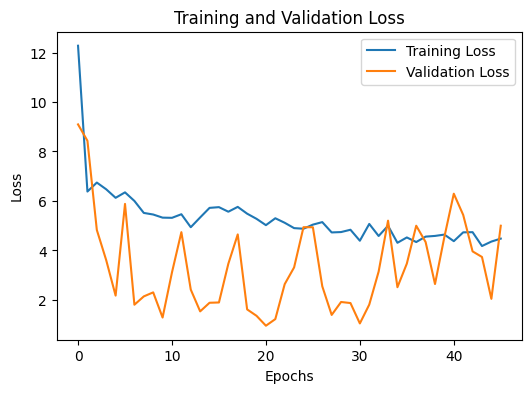

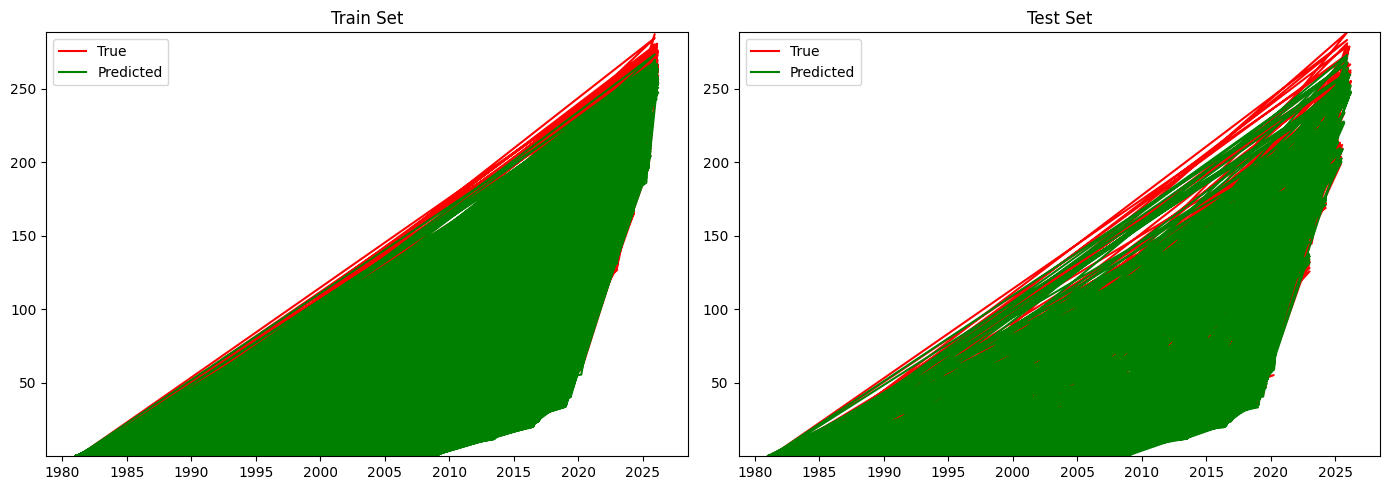

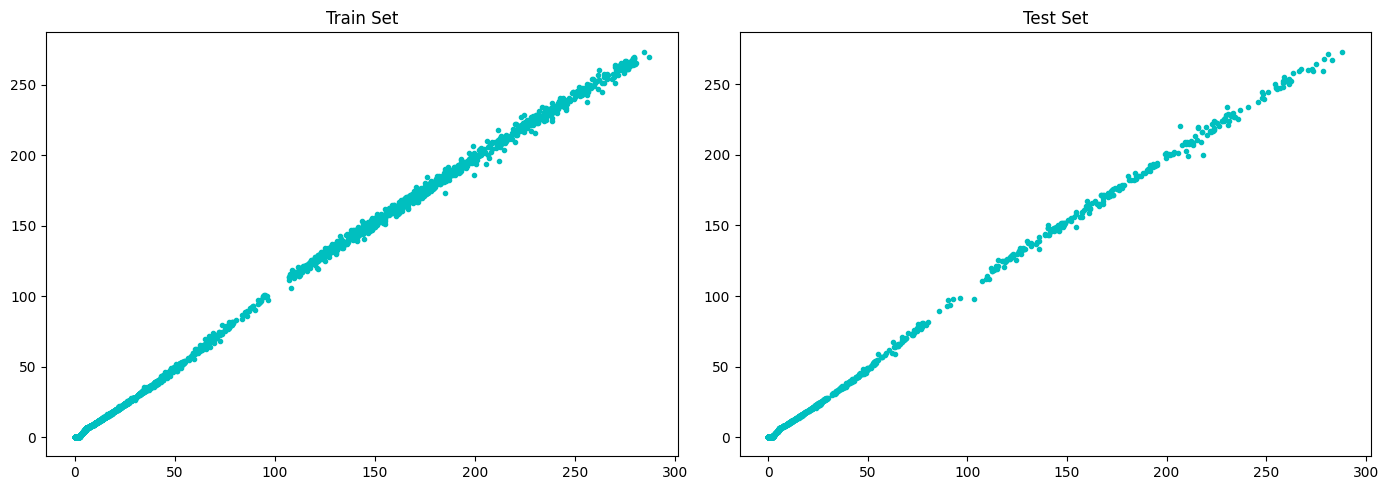

MAE:
  Train: 0.9799
  Test:  0.9574
R^2:
  Train: 0.9989
  Test:  0.9988


In [33]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# Get predictions
y_train_pred = model_dense.predict(X_train)[:,0]
y_test_pred  = model_dense.predict(X_test)[:,0]

# Create a figure with two subplots side by side
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# Left subplot: Training and Validation Loss
ax.plot(history_dense.history['loss'], label='Training Loss')
ax.plot(history_dense.history['val_loss'], label='Validation Loss')
ax.set_title('Training and Validation Loss')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.legend()

r2_train = r2_score(y_train, y_train_pred)
print(f'r2_train:   {r2_train:.5}')

r2_test = r2_score(y_test, y_test_pred)
print(f'r2_test:    {r2_test:.5}')

rmse_train = mean_squared_error(y_train, y_train_pred)**0.5
print(f'rmse_train: {rmse_train:.5}')

rmse_test = mean_squared_error(y_test, y_test_pred)**0.5
print(f'rmse_test:  {rmse_test:.5}')

y_train_pred = pd.Series(y_train_pred, index=dates_train)
y_test_pred  = pd.Series(y_test_pred, index=dates_test)

# Calculate global y-axis limits
y_min = min(y_train.min(), y_train_pred.min(), y_test.min(), y_test_pred.min())
y_max = max(y_train.max(), y_train_pred.max(), y_test.max(), y_test_pred.max())

# Plot train and test side by side with shared y limits
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(dates_train, y_train, 'r', label='True')
axs[0].plot(y_train_pred, 'g', label='Predicted')
axs[0].set_title('Train Set')
axs[0].set_ylim(y_min, y_max)
axs[0].legend()

axs[1].plot(dates_test, y_test, 'r', label='True')
axs[1].plot(y_test_pred, 'g', label='Predicted')
axs[1].set_title('Test Set')
axs[1].set_ylim(y_min, y_max)
axs[1].legend()

plt.tight_layout()
plt.show()

# Plot train and test side by side with shared y limits
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(y_train, y_train_pred.values, 'c.')
axs[0].set_title('Train Set')
# axs[0].legend() # Removed as there's no label for scatter plot

axs[1].plot(y_test, y_test_pred.values, 'c.')
axs[1].set_title('Test Set')
# axs[1].legend() # Removed as there's no label for scatter plot

plt.tight_layout()
plt.show()

mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print("MAE:")
print(f"  Train: {mae_train:.4f}")
print(f"  Test:  {mae_test:.4f}")
print("R^2:")
print(f"  Train: {r2_train:.4f}")
print(f"  Test:  {r2_test:.4f}")

# LSTM

In [34]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay, PolynomialDecay

# define training parameters
epochs          = 500
batch_size      = 256
decay_epochs    = int( epochs * 0.5 )

n_train         = X_train.shape[0]
steps_per_epoch = int( np.ceil( n_train / batch_size ) )
decay_steps     = decay_epochs * steps_per_epoch
#print(decay_steps)

# Define the learning rate schedule
initial_learning_rate = 0.05

lr_schedule_exp = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_rate=5.0,
    decay_steps=decay_steps
)

lr_schedule_poly = PolynomialDecay(
    initial_learning_rate=initial_learning_rate,
    end_learning_rate=0.001,
    decay_steps=decay_steps,
    power=1.0
)

# Define the optimizer with a custom learning rate
optimizer = Adam(
    learning_rate=initial_learning_rate,
    #learning_rate=lr_schedule_exp,
    #learning_rate=lr_schedule_poly,
    #clipnorm=1,
    #clipvalue=1,
)

# Compile model
model.compile(
    optimizer=optimizer,
    loss='mae'
)

In [35]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=50,          # Stop after 5 epochs without improvement
    restore_best_weights=True  # Restore the best weights after stopping
)

# Callback to reduce LR when a monitored metric has stopped improving
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',       # metric to monitor
    factor=0.5,               # factor by which to reduce the LR
    patience=50,              # number of epochs with no improvement after which LR will be reduced
    min_lr=1e-6,              # lower bound on the learning rate
    verbose=1                 # print when LR is reduced
)

In [38]:
X_train_2 = X_train.values.reshape((X_train.shape[0], window_size, X_train.shape[1] // window_size))
X_test_2 = X_test.values.reshape((X_test.shape[0], window_size, X_test.shape[1] // window_size))

model_lstm = Sequential([
    Input(shape=(window_size, X_train.shape[1] // window_size)), # Corrected input shape

    LSTM(64, return_sequences=True),
    Dropout(0.2),
    BatchNormalization(),

    LSTM(32, return_sequences=False),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dense(1)
])

# Define the optimizer with a custom learning rate
optimizer = Adam(learning_rate=0.001)

# Compile model
model_lstm .compile(
    optimizer=optimizer,
    loss='mae',
)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=25,          # Stop after 5 epochs without improvement
    restore_best_weights=True  # Restore the best weights after stopping
)

model_lstm .summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 10, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,913 (120.75 KB)

 Trainable params: 30,785 (120.25 KB)

 Non-trainable params: 128 (512.00 B)

In [39]:
history_lstm = model_lstm.fit(
    X_train_2, y_train,
    epochs=150,
    batch_size=64,
    validation_data=(X_test_2, y_test),
    verbose=1,
    callbacks=[early_stopping]
)

Epoch 1/150
143/143 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 23.3016 - val_loss: 16.8154
Epoch 2/150
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 13.3889 - val_loss: 8.1186
Epoch 3/150
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5.9744 - val_loss: 4.3252
Epoch 4/150
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.2855 - val_loss: 2.3903
Epoch 5/150
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.5346 - val_loss: 3.0546
Epoch 6/150
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.4567 - val_loss: 1.8430
Epoch 7/150
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.2707 - val_loss: 1.2776
Epoch 8/150
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.1187 - val_loss: 1.3620
Epoch 9/150
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.1218 - val_loss: 1.5516
Epoch 10/150
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.0974 - val_loss: 2.0227
Epoch 11/150
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.0464 - val_loss: 1.2682
Epoch 12/150
143/143 ━━━━━━━━━━━━━━━━━

285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


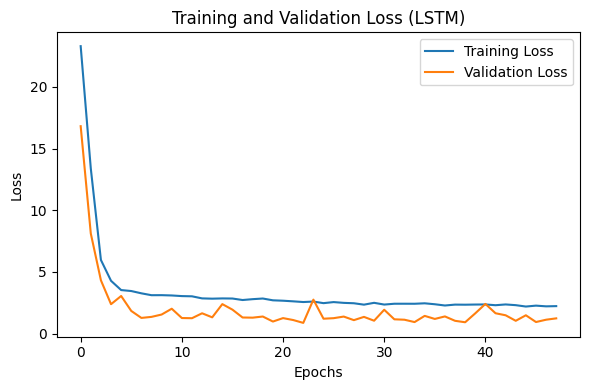

r2_train:   0.99815
r2_test:    0.99822
rmse_train: 2.6089
rmse_test:  2.4955


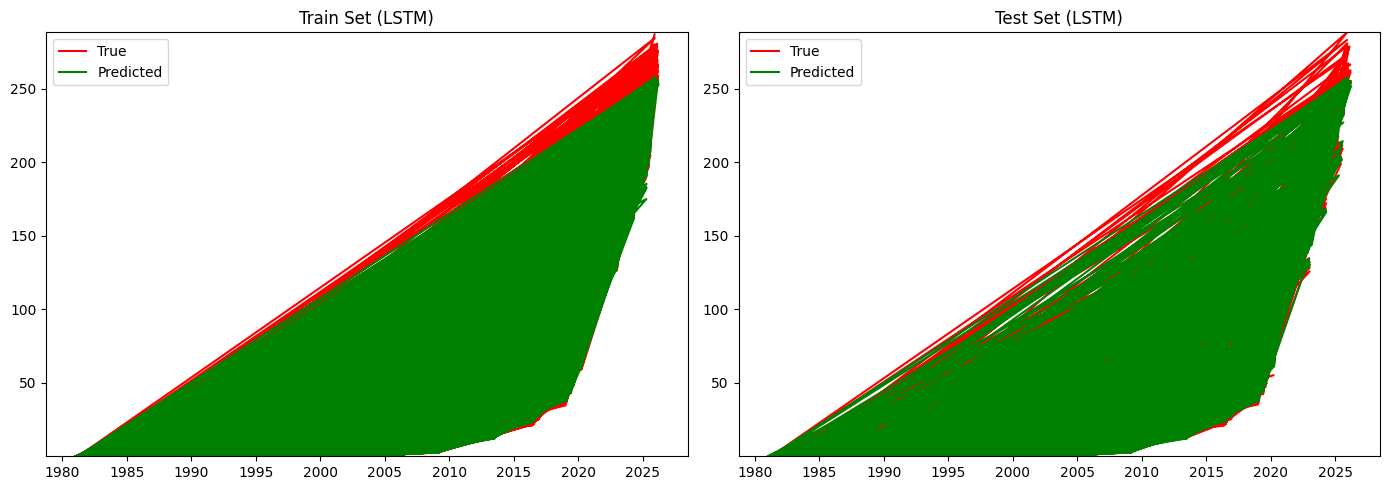

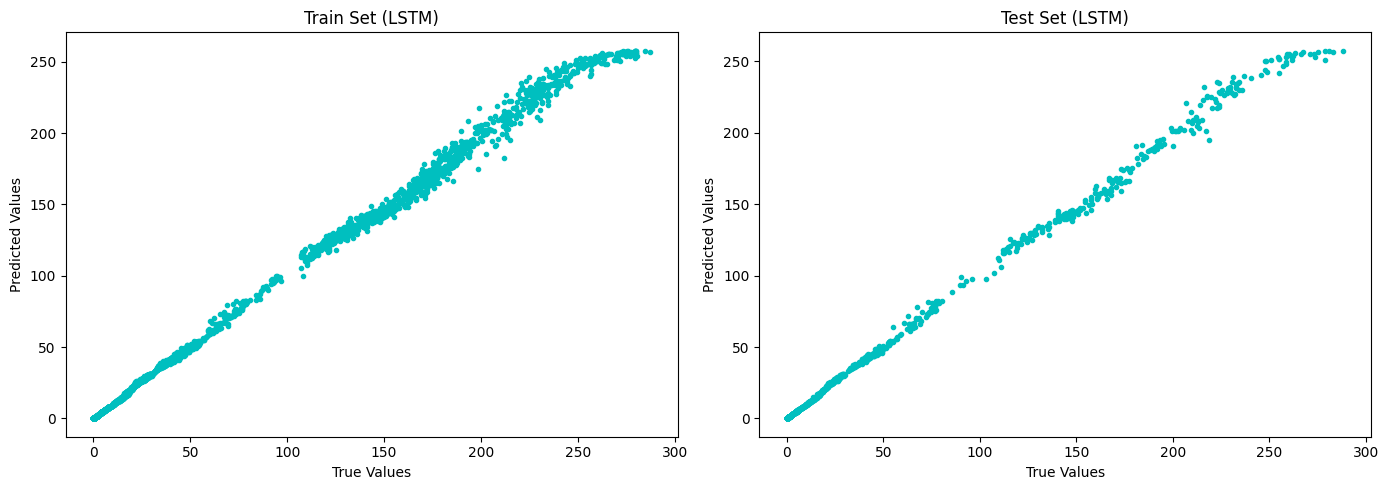

MAE:
  Train: 0.9334
  Test:  0.8750
R^2:
  Train: 0.9981
  Test:  0.9982


In [41]:
# Get predictions
# Use the already reshaped X_train_2 and X_test_2 for LSTM predictions.
y_train_pred = model_lstm.predict(X_train_2)[:,0]
y_test_pred  = model_lstm.predict(X_test_2)[:,0]

# Now use the true values and dates from the train_test_split
y_train_true = y_train
y_test_true = y_test
dates_train_plot = dates_train
dates_test_plot = dates_test

# Create a figure with one subplot for loss
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# Plot Training and Validation Loss
ax.plot(history_lstm.history['loss'], label='Training Loss')
ax.plot(history_lstm.history['val_loss'], label='Validation Loss')
ax.set_title('Training and Validation Loss (LSTM)')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.legend()
plt.tight_layout()
plt.show()

# Calculate metrics for LSTM model
r2_train = r2_score(y_train_true, y_train_pred)
print(f'r2_train:   {r2_train:.5}')

r2_test = r2_score(y_test_true, y_test_pred)
print(f'r2_test:    {r2_test:.5}')

rmse_train = mean_squared_error(y_train_true, y_train_pred)**0.5
print(f'rmse_train: {rmse_train:.5}')

rmse_test = mean_squared_error(y_test_true, y_test_pred)**0.5
print(f'rmse_test:  {rmse_test:.5}')

# Convert predictions to pandas Series with dates as index for plotting
y_train_pred_series = pd.Series(y_train_pred, index=dates_train_plot)
y_test_pred_series  = pd.Series(y_test_pred, index=dates_test_plot)

# Calculate global y-axis limits for consistent plotting
y_min = min(y_train_true.min(), y_train_pred_series.min(), y_test_true.min(), y_test_pred_series.min())
y_max = max(y_train_true.max(), y_train_pred_series.max(), y_test_true.max(), y_test_pred_series.max())

# Plot train and test side by side with shared y limits
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(dates_train_plot, y_train_true, 'r', label='True')
axs[0].plot(y_train_pred_series, 'g', label='Predicted')
axs[0].set_title('Train Set (LSTM)')
axs[0].set_ylim(y_min, y_max)
axs[0].legend()

axs[1].plot(dates_test_plot, y_test_true, 'r', label='True')
axs[1].plot(y_test_pred_series, 'g', label='Predicted')
axs[1].set_title('Test Set (LSTM)')
axs[1].set_ylim(y_min, y_max)
axs[1].legend()

plt.tight_layout()
plt.show()

# Plot scatter plots for train and test side by side with shared y limits
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(y_train_true, y_train_pred_series.values, 'c.')
axs[0].set_title('Train Set (LSTM)')
axs[0].set_xlabel('True Values')
axs[0].set_ylabel('Predicted Values')
# axs[0].legend() # Removed as there's no label for scatter plot

axs[1].plot(y_test_true, y_test_pred_series.values, 'c.')
axs[1].set_title('Test Set (LSTM)')
axs[1].set_xlabel('True Values')
axs[1].set_ylabel('Predicted Values')
# axs[1].legend() # Removed as there's no label for scatter plot

plt.tight_layout()
plt.show()

mae_train = mean_absolute_error(y_train_true, y_train_pred)
mae_test = mean_absolute_error(y_test_true, y_test_pred)

print("MAE:")
print(f"  Train: {mae_train:.4f}")
print(f"  Test:  {mae_test:.4f}")
print("R^2:")
print(f"  Train: {r2_train:.4f}")
print(f"  Test:  {r2_test:.4f}")

In [46]:
# Create a DataFrame to organize the data of true vs pred data graph
predicted_results_df_corrected = pd.DataFrame({
    'Actual Close Price': pd.Series(y_test_true, index=dates_test_plot), # Use y_test_true and dates_test_plot
    'Predicted Stock Price': pd.Series(y_test_pred, index=dates_test_plot),
    'Difference (Error)': (pd.Series(y_test_true, index=dates_test_plot) - pd.Series(y_test_pred, index=dates_test_plot)),
    'Percentage Error (%)': ((abs(pd.Series(y_test_true, index=dates_test_plot) - pd.Series(y_test_pred, index=dates_test_plot))) / pd.Series(y_test_true, index=dates_test_plot)) * 100
})

# Get the original 'Open' prices from the stocks DataFrame using dates_test_plot's index
# Note: 'stocks' DataFrame has 'Open' (capital O) column
open_prices = stocks.loc[dates_test_plot, ['Open']]

# Merge this information into predicted_results_df, aligning by index
predicted_results_df_corrected = predicted_results_df_corrected.merge(open_prices, left_index=True, right_index=True)

# Reorder columns for clarity, putting 'Open' and 'Actual Close Price' first
predicted_results_df_corrected = predicted_results_df_corrected[[
    'Open', 'Actual Close Price', 'Predicted Stock Price',
    'Difference (Error)', 'Percentage Error (%)'
]]

# Sort the DataFrame by its index (dates) to enable proper time-series slicing
predicted_results_df_corrected = predicted_results_df_corrected.sort_index()

# Display the corrected numerical table filtered from 2007 to 2026
display(predicted_results_df_corrected.loc['2007':'2026'])

,Open,Actual Close Price,Predicted Stock Price,Difference (Error),Percentage Error (%)
2007-01-23,2.568729,2.622062,2.751535,-0.129473,4.937820
2007-02-02,2.520488,2.554346,2.627806,-0.073460,2.875879
2007-02-08,2.559739,2.592100,2.592688,-0.000589,0.022706
2007-02-12,2.529776,2.552249,2.602941,-0.050692,1.986179
2007-02-15,2.560040,2.565432,2.581042,-0.015610,0.608467
...,...,...,...,...,...
2026-03-02,262.410004,266.529999,255.430466,11.099533,4.164459
2026-03-09,255.690002,261.149994,253.887604,7.262390,2.780927
2026-03-10,257.649994,262.480011,253.792068,8.687943,3.309944
2026-03-17,252.960007,255.130005,252.033768,3.096237,1.213592


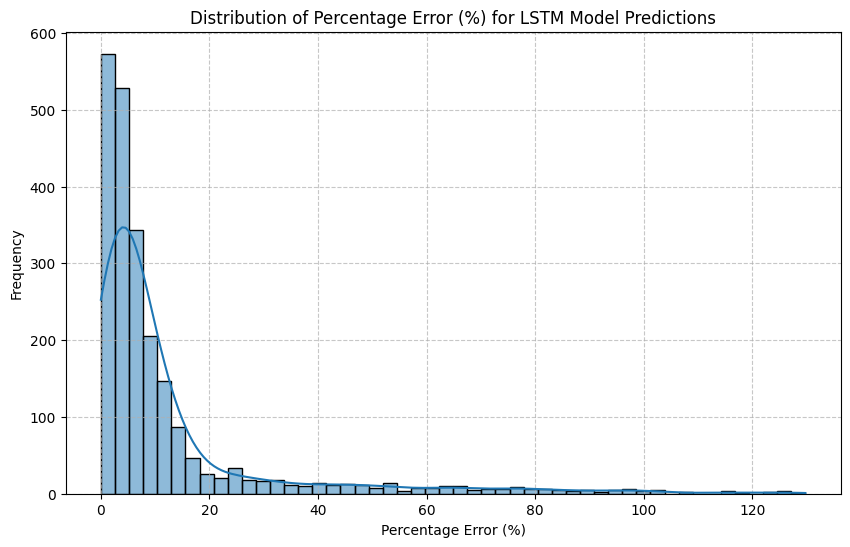

In [47]:
plt.figure(figsize=(10, 6))
sns.histplot(predicted_results_df_corrected['Percentage Error (%)'], bins=50, kde=True)
plt.title('Distribution of Percentage Error (%) for LSTM Model Predictions')
plt.xlabel('Percentage Error (%)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [48]:
stocks.tail(50)

,Open,High,Low,Close,Volume
Date,,,,,
2026-01-06,266.750392,267.299866,261.874950,262.114716,52352100
2026-01-07,262.953951,263.433483,259.567106,260.086609,48309800
2026-01-08,256.779720,259.047618,255.460962,258.797852,50419300
2026-01-09,258.837796,259.966744,255.980484,259.127533,39997000
2026-01-12,258.917736,261.055720,256.559927,260.006714,45263800
2026-01-13,258.478130,261.565238,258.148452,260.805939,45730800
2026-01-14,259.247418,261.575257,256.470018,259.716980,40019400
2026-01-15,260.406319,260.795969,256.809678,257.968597,39388600
2026-01-16,257.658902,258.657967,254.691677,255.291122,72142800
